In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

#from analysis.utils import load_sweep_metadata, load_data

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



## Utils

In [43]:
def run_env_autonomous(env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    #env.reset()
    obs_list = []
    obs_list.append(obs)
    for _ in range(n_steps - 1):
        next_obs, reward, done, info = env.step(torch.tensor([0.0]))
        obs_list.append(next_obs)

    return np.array(obs_list)


@torch.no_grad()
def run_dynamics_model(agent, env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    z = agent.model.encode(obs.to(agent.device), task=None)

    obs_list = []
    obs_list.append(obs)
    z_list = []
    z_list.append(z.cpu().numpy())
    for _ in range(n_steps - 1):
        #next_obs, *_ = env.step(torch.tensor([0.0]))

        z = agent.model.next(z, torch.tensor([0.0]).to(agent.device), task=None)
        z_list.append(z.cpu().numpy())
        #obs_list.append(next_obs)

    return np.array(z_list)


@torch.no_grad()
def run_dynamics_model_in_steps(agent, env, initial_state, n_steps=100, k=10):
    obs = env.reset(initial_state=initial_state)
    z = agent.model.encode(obs.to(agent.device), task=None)

    obs_list = []
    z_list = []
    obs_list.append(obs)
    z_list.append(z.cpu().numpy())
    for step in range(0, n_steps - 1, k):
        steps_in_chunk = min(k, n_steps - 1 - step)
        for _ in range(steps_in_chunk):

            next_obs, *_ = env.step(torch.tensor([0.0]))
            z = agent.model.next(z,
                                 torch.tensor([0.0]).to(agent.device),
                                 task=None)

            z_list.append(z.cpu().numpy())
            obs_list.append(next_obs)
        z = agent.model.encode(next_obs.to(agent.device), task=None)
        #z_list.append(z.cpu().numpy())
    return np.array(z_list), np.array(obs_list)

In [59]:
CKPT_TO_USE = 500_000

## read data

In [60]:
from analysis.utils import load_sweep_metadata, load_data

df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))

df = df[df['ckpt_int'] == CKPT_TO_USE]
z_nonautonomous = np.concatenate(df['latent_states'].tolist())
obs_nonautonomous = np.concatenate(df['observations'].tolist())

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 7909.77it/s]


Found 108 configurations
Found 108 configurations


  0%|          | 0/108 [00:00<?, ?it/s]

100%|██████████| 108/108 [00:00<00:00, 343.80it/s]


## Initialize environment and agent

In [61]:
# Base configuration
CKPT_PATH = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'
#CKPT_PATH = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-noncentered.pt'
override_cfg = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,  # Disable video to speed up sweep
    record_planning=False,  # Focus on episode data
)

with initialize(config_path="tdmpc2", version_base=None):
    cfg = compose(config_name="config")
    OmegaConf.set_struct(cfg, False)
    cfg = OmegaConf.merge(cfg, override_cfg)

# Parse config
cfg = parse_cfg(cfg)
set_seed(cfg.seed)

cfg.initial_state = {
    'qpos': {
        'slider': 0,  #cart position
        'hinge_1': 0,  # pole angle
    },
}

env = make_env(cfg)

print("\nLoading agent...")
agent = TDMPC2(cfg)

# Optionally load checkpoint
if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
    print(f"Loading checkpoint: {cfg.checkpoint}")
    agent.load(cfg.checkpoint)


Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


## Train linear probe

In [62]:
def simulate_autonomous_data(env,
                             agent,
                             initial_positions=[0],
                             initial_angles=None,
                             steps_to_run=50):
    from itertools import product

    if initial_angles is None:
        initial_angles = np.linspace(0, 360, 11)

    obs = []
    z = []
    for initial_position, initial_angle in tqdm(
            product(initial_positions, initial_angles)):
        initial_angle_radians = np.radians(initial_angle)
        initial_state = {
            'qpos': {
                'slider': initial_position,  #cart position
                'hinge_1': initial_angle_radians,  # pole angle
            },
            'qvel': {
                #'slider': 0,  #cart velocity
                #'hinge_1': 0,  # pole angular velocity
            }
        }

        obs_true = run_env_autonomous(env, initial_state, steps_to_run)
        z_true = agent.model.encode(torch.from_numpy(obs_true).to(agent.device),
                                    task=None).detach().cpu().numpy()

        obs.append(obs_true)
        z.append(z_true)

    return np.concatenate(obs), np.concatenate(z)

In [63]:
obs_autonomous, z_autonomous = simulate_autonomous_data(
    env,
    agent,
    initial_positions=[-1, 0, 1],
    initial_angles=None,
    steps_to_run=50)

0it [00:00, ?it/s]

33it [00:00, 60.71it/s]


In [64]:
obs_autonomous.shape, z_autonomous.shape

((1650, 5), (1650, 512))

In [65]:
# Collect all latents and observations
all_latents = []
all_observations = []

# Concatenate all |episodes
X = np.concatenate([z_autonomous, z_nonautonomous])
y = np.concatenate([obs_autonomous, obs_nonautonomous])
print(X.shape, y.shape)
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

# Fit linear probe for each observation dimension
probe = LinearRegression()
probe.fit(X_train, y_train)
y_pred = probe.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R²: {np.mean(r2):.4f}")

(10650, 512) (10650, 5)
R²: 0.9999


In [113]:
intital_positions = [0]
initial_angles = np.linspace(0, 360, 11)[1:-1]
steps_to_run = 50

results = {}
for initial_position, initial_angle in tqdm(
        product(intital_positions, initial_angles)):
    initial_angle_radians = np.radians(initial_angle)
    initial_state = {
        'qpos': {
            'slider': initial_position,  #cart position
            'hinge_1': initial_angle_radians,  # pole angle
        },
        'qvel': {
            'slider': 0,  #cart velocity
            'hinge_1': 0,  # pole angular velocity
        }
    }

    obs_true = run_env_autonomous(env, initial_state, steps_to_run)
    z_true = agent.model.encode(torch.from_numpy(obs_true).to(agent.device),
                                task=None).detach().cpu().numpy()

    z_predicted = run_dynamics_model(agent, env, initial_state, steps_to_run)
    obs_predicted = probe.predict(z_predicted)

    dict_results_steps = {}
    for k in list(range(1, 10 + 1)) + [20] + [30] + [40] + [50]:
        z_predicted_steps, obs_true_steps = run_dynamics_model_in_steps(
            agent, env, initial_state, n_steps=steps_to_run, k=k)
        obs_predicted_steps = probe.predict(z_predicted_steps)
        dict_results_steps[f'z_predicted_steps_{k}'] = z_predicted_steps
        #dict_results_steps[f'obs_true_steps_{k}'] = obs_true_steps
        dict_results_steps[f'obs_predicted_steps_{k}'] = obs_predicted_steps

    errors_latent = (abs(z_true - z_predicted)).mean(1)
    errors_physical = (abs(obs_true - obs_predicted)).mean(1)
    error_physical_per_dim = [
        (abs(obs_true[:, i] - obs_predicted[:, i])).mean() for i in range(5)
    ]
    error_latent_per_dim = [
        (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
    ]
    r2_physical = r2_score(obs_true, obs_predicted)
    r2_physical_per_dim = [
        r2_score(obs_true[:, i], obs_predicted[:, i]) for i in range(5)
    ]
    r2_latent = r2_score(z_true, z_predicted)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
    variance_obs_true_per_dim = np.var(obs_true, axis=0)
    variance_obs_predicted_per_dim = np.var(obs_predicted, axis=0)

    results[(initial_position, initial_angle)] = {
        'obs_true': obs_true,
        'obs_predicted': obs_predicted,
        'z_true': z_true,
        'z_predicted': z_predicted,
        **dict_results_steps,
        'errors_latent': errors_latent,
        'errors_physical': errors_physical,
        'error_physical_per_dim': error_physical_per_dim,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_physical': r2_physical,
        'r2_physical_per_dim': r2_physical_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
        'variance_obs_true_per_dim': variance_obs_true_per_dim,
        'variance_obs_predicted_per_dim': variance_obs_predicted_per_dim,
    }

0it [00:00, ?it/s]

4it [00:02,  1.47it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/metrics/_regression.py:940: RuntimeWarning: overflow encountered in divide
  numerator[valid_score] / denominator[valid_score]
9it [00:06,  1.47it/s]


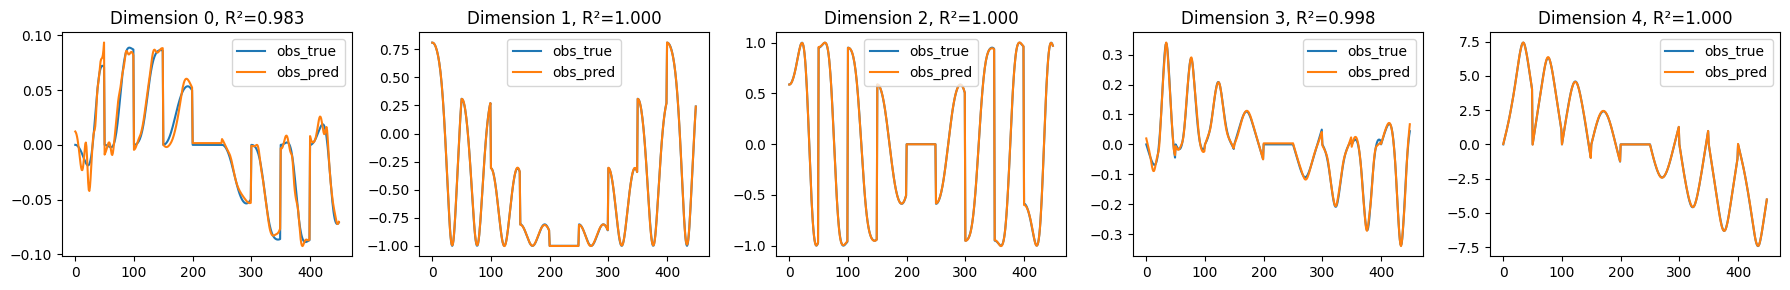

In [114]:
# Stack all z_true and obs_true for this checkpoint
z_true_all = []
obs_true_all = []

for key in results.keys():
    initial_position, initial_angle = key
    z_true_all.append(results[key]['z_true'])
    obs_true_all.append(results[key]['obs_true'])

# Stack them together
z_true_stacked = np.vstack(z_true_all)
obs_true_stacked = np.vstack(obs_true_all)

# Predict on all stacked data
obs_pred_stacked = probe.predict(z_true_stacked)

# Plot
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for dim in range(5):
    r2 = r2_score(obs_true_stacked[:, dim], obs_pred_stacked[:, dim])
    axes[dim].plot(obs_true_stacked[:, dim], label='obs_true')
    axes[dim].plot(obs_pred_stacked[:, dim], label='obs_pred')
    axes[dim].set_title(f'Dimension {dim}, R²={r2:.3f}')
    axes[dim].legend()
plt.tight_layout()
plt.show()

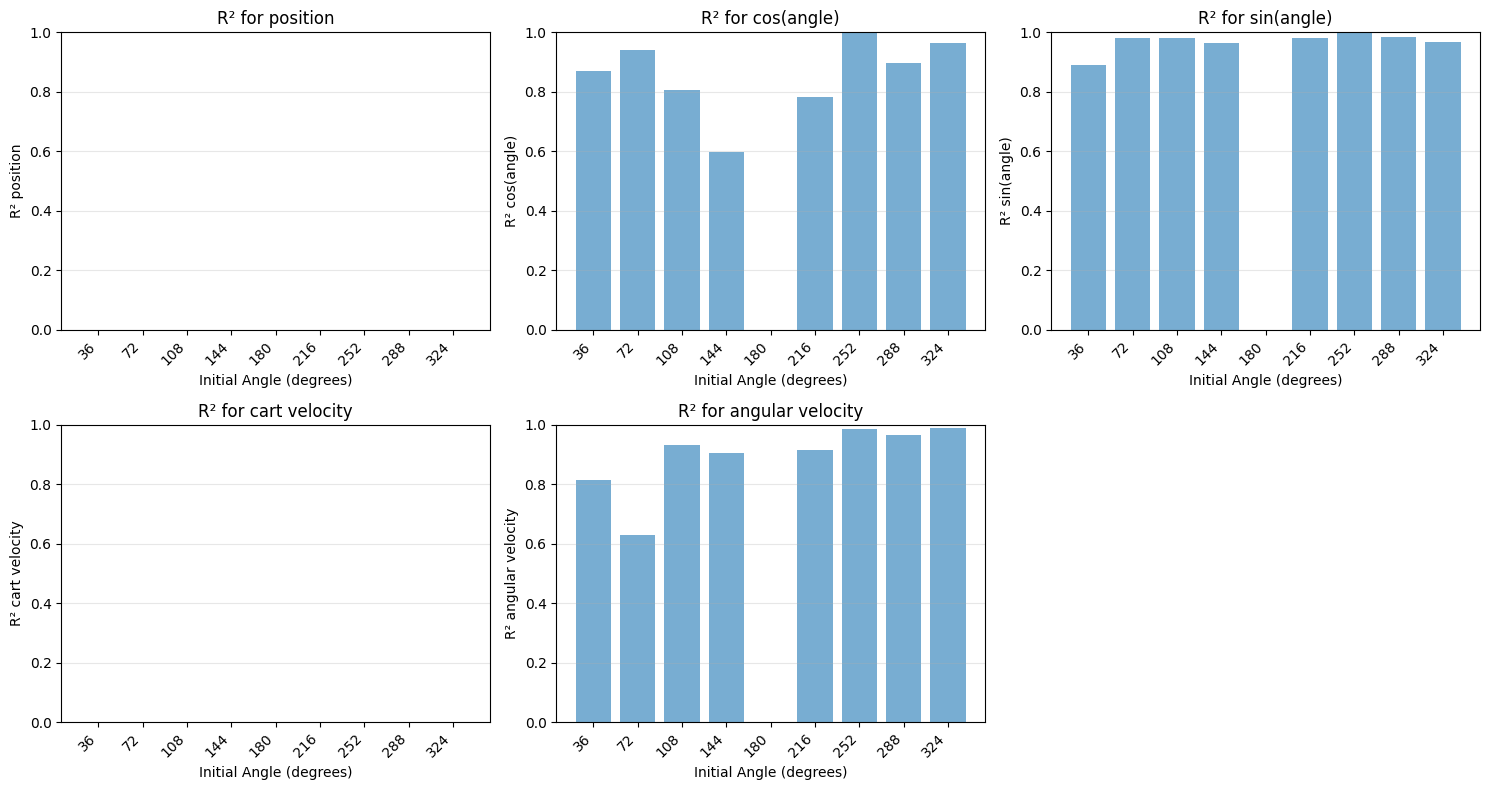

In [115]:
# Plot R² physical per dimension for each initial condition
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    initial_angles_list = []
    r2_physical_per_dim_list = []

    for (initial_position, initial_angle), result in results.items():
        initial_angles_list.append(initial_angle)
        r2_physical_per_dim_list.append(result['r2_physical_per_dim'][dim])

    ax = axes[dim]
    ax.bar(range(len(initial_angles_list)), r2_physical_per_dim_list, alpha=0.6)
    ax.set_xlabel('Initial Angle (degrees)')
    ax.set_ylabel(f'R² {variable_names[dim]}')
    ax.set_ylim(0, 1)
    ax.set_title(f'R² for {variable_names[dim]}')
    ax.set_xticks(range(len(initial_angles_list)))
    ax.set_xticklabels([f'{angle:.0f}' for angle in initial_angles_list],
                       rotation=45,
                       ha='right')
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


In [116]:
results[(0, 324)]['variance_obs_true_per_dim']

array([1.0816763e-03, 4.0029678e-01, 5.2357882e-01, 1.8969627e-02,
       5.4493480e+00], dtype=float32)

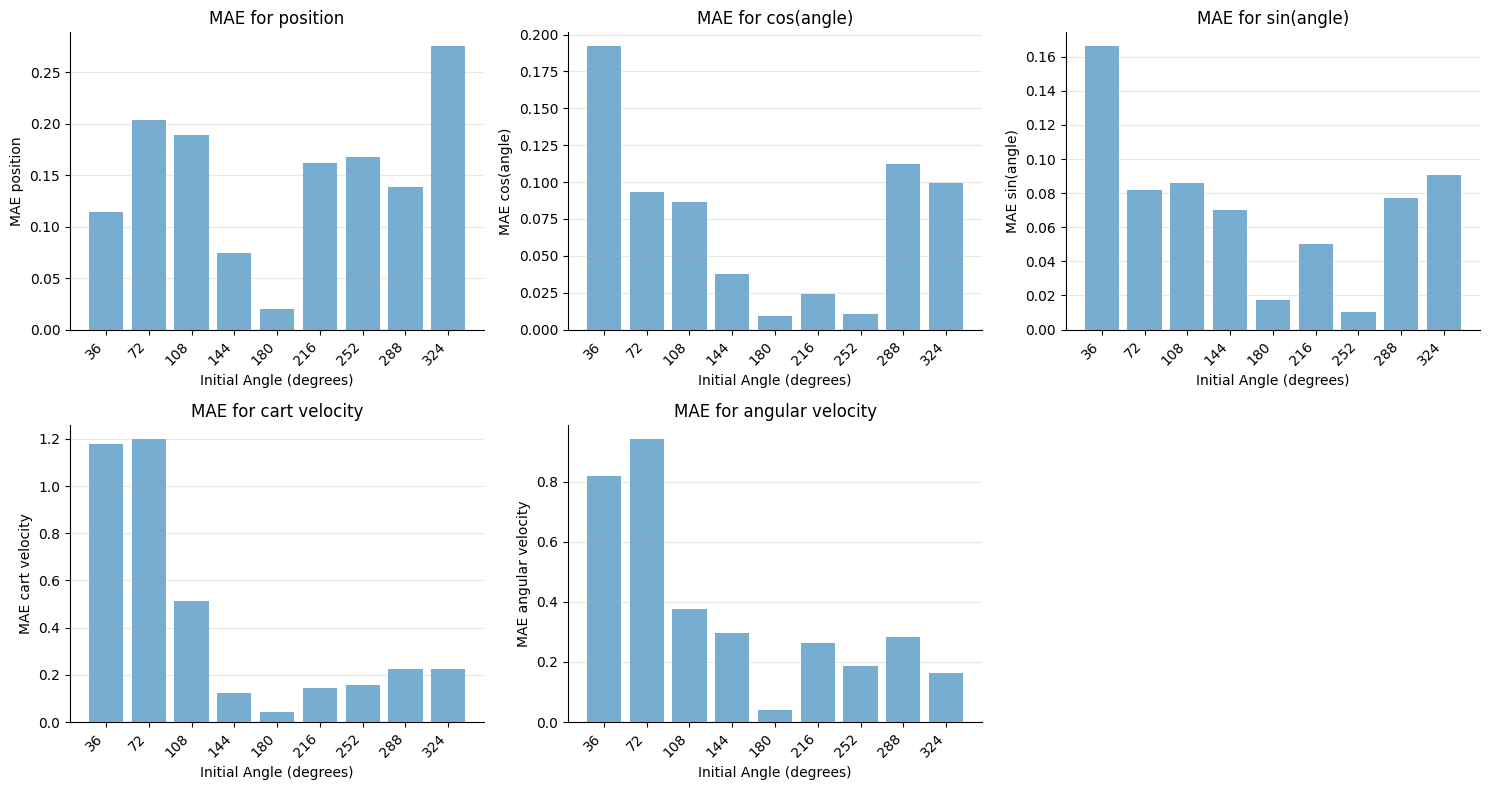

In [117]:
# Plot R² physical per dimension for each initial condition
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    initial_angles_list = []
    r2_physical_per_dim_list = []

    for (initial_position, initial_angle), result in results.items():
        initial_angles_list.append(initial_angle)
        r2_physical_per_dim_list.append(result['error_physical_per_dim'][dim])

    ax = axes[dim]
    ax.bar(range(len(initial_angles_list)), r2_physical_per_dim_list, alpha=0.6)
    ax.set_xlabel('Initial Angle (degrees)')
    ax.set_ylabel(f'MAE {variable_names[dim]}')
    #ax.set_ylim(0, 1)
    ax.set_title(f'MAE for {variable_names[dim]}')
    ax.set_xticks(range(len(initial_angles_list)))
    ax.set_xticklabels([f'{angle:.0f}' for angle in initial_angles_list],
                       rotation=45,
                       ha='right')
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()


In [120]:
# _ = reconstruct_cartpole_dmcontrol(
#     results[(0, 324)]['obs_true'],
#     save_video=True,
#     out_path=
#     f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_true_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
# )

# _ = reconstruct_cartpole_dmcontrol(
#     results[(0, 288)]['obs_predicted'],
#     save_video=True,
#     out_path=
#     f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_steps_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
# )

In [121]:
# obs_predicted_with_true_positions = results[(0, 108)]['obs_predicted']
# obs_predicted_with_true_positions[:, 0] = results[(0, 108)]['obs_true'][:, 0]
# reconstruct_cartpole_dmcontrol(
#     #results[(0, 324)]['obs_predicted'],
#     obs_predicted_with_true_positions,
#     save_video=True,
#     out_path=
#     f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
# )

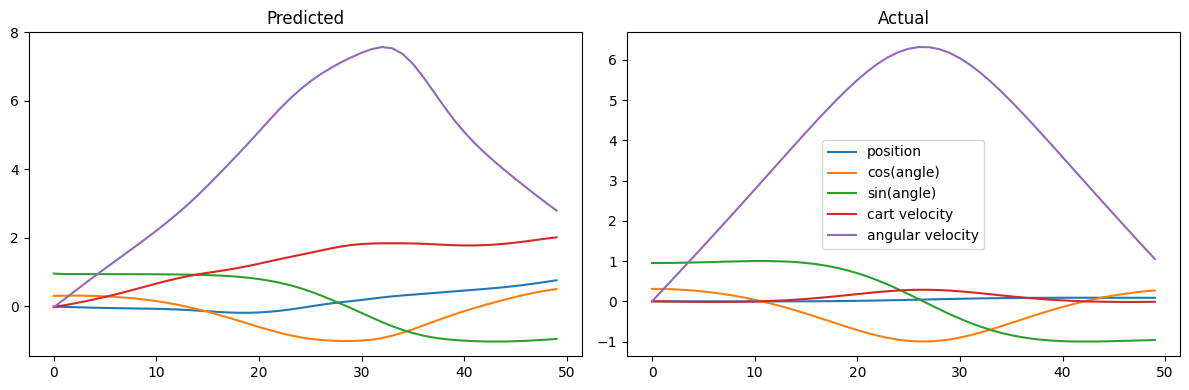

In [122]:
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

steps_to_plot = 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for i in range(5):
    ax1.plot(results[(0, 72)]['obs_predicted'][:steps_to_plot, i],
             label=variable_names[i])
ax1.set_title('Predicted')

for i in range(5):
    ax2.plot(results[(0, 72)]['obs_true'][:steps_to_plot, i],
             label=variable_names[i])
ax2.set_title('Actual')
plt.legend()
plt.tight_layout()

In [123]:
# errors_latent = ((z_true - z_predicted)**2).mean(1)
# errors_physical = ((obs_true - obs_predicted)**2).mean(1)

# r2_physical = r2_score(obs_true[:steps_to_plot], obs_predicted[:steps_to_plot])

# r2_physical_per_dim = [
#     r2_score(obs_true[:steps_to_plot, i], obs_predicted[:steps_to_plot, i])
#     for i in range(5)
# ]
# r2_latent = r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
# r2_latent_per_dim = [
#     r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
#     for i in range(512)
# ]

# variance_per_dim = np.var(z_true[:steps_to_plot], axis=0)

# r2_physical = r2_score(obs_true[:steps_to_plot], obs_predicted[:steps_to_plot])

# r2_physical_per_dim = [
#     r2_score(obs_true[:steps_to_plot, i], obs_predicted[:steps_to_plot, i])
#     for i in range(5)
# ]
# r2_latent = r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
# r2_latent_per_dim = [
#     r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
#     for i in range(512)
# ]

# variance_per_dim = np.var(z_true[:steps_to_plot], axis=0)

# sorted_variance = sorted(variance_per_dim, reverse=True)

# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(sorted_variance, linewidth=2, color='steelblue', alpha=0.8)
# ax.set_xlabel('Latent Dimension (sorted by variance)', fontsize=12)
# ax.set_ylabel('Variance', fontsize=12)
# ax.set_title('Variance per Latent Dimension (Sorted)',
#              fontsize=14,
#              fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')
# plt.tight_layout()
# plt.show()

In [124]:
# fig, ax = plt.subplots(figsize=(12, 5))

# # Sort R² scores by magnitude
# sorted_r2 = sorted(r2_latent_per_dim, reverse=True)

# ax.plot(sorted_r2, linewidth=2, color='steelblue', alpha=0.8)
# ax.set_ylim(0, 1)
# ax.set_xlabel('Latent Dimension (sorted by R²)', fontsize=12)
# ax.set_ylabel('R² Score', fontsize=12)
# ax.set_title('R² Score per Latent Dimension (Sorted)',
#              fontsize=14,
#              fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')

# # # Plot red dots at y=0 for dimensions with R² < 1
# # low_r2_count = sum(1 for r2 in sorted_r2 if r2 < 1)
# # if low_r2_count > 0:
# #     low_r2_indices = [i for i, r2 in enumerate(sorted_r2) if r2 < 1]
# #     ax.scatter(low_r2_indices, [0] * len(low_r2_indices),
# #                color='red',
# #                s=20,
# #                alpha=0.6,
# #                label=f'R² < 1 ({low_r2_count} dims)',
# #                zorder=5)
# #     ax.legend()

# plt.tight_layout()
# plt.show()

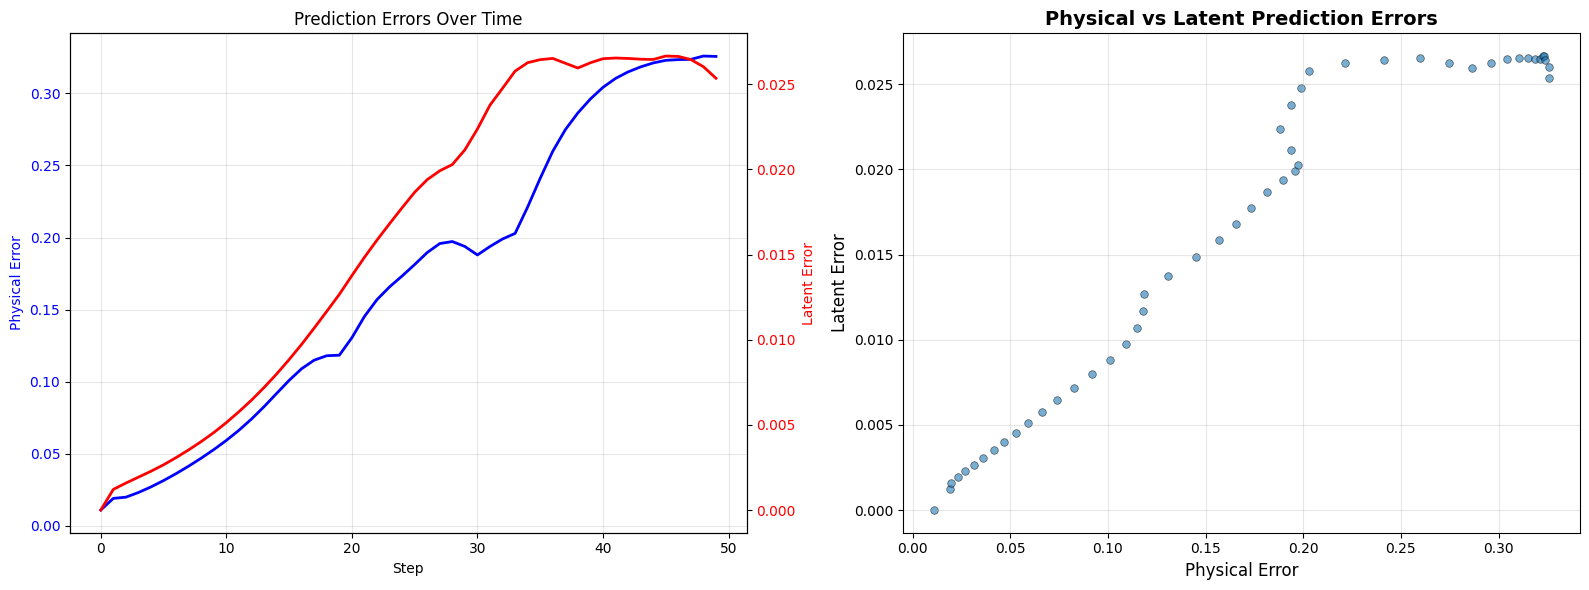

In [125]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Time series of errors with dual y-axes
ax1_left = ax1
ax1_left.plot(errors_physical, 'b-', label='Physical', linewidth=2)
ax1_left.set_xlabel('Step')
ax1_left.set_ylabel('Physical Error', color='b')
ax1_left.tick_params(axis='y', labelcolor='b')
ax1_left.grid(True, alpha=0.3)

# Create second y-axis for latent errors
ax1_right = ax1.twinx()
ax1_right.plot(errors_latent, 'r-', label='Latent', linewidth=2)
ax1_right.set_ylabel('Latent Error', color='r')
ax1_right.tick_params(axis='y', labelcolor='r')

ax1.set_title('Prediction Errors Over Time')

# Right plot: Scatter plot
ax2.scatter(errors_physical,
            errors_latent,
            alpha=0.6,
            s=30,
            edgecolors='k',
            linewidth=0.5)
ax2.set_xlabel('Physical Error', fontsize=12)
ax2.set_ylabel('Latent Error', fontsize=12)
ax2.set_title('Physical vs Latent Prediction Errors',
              fontsize=14,
              fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis of the dynamcis with predicted steps

In [126]:
angle_to_analyze = 324

In [127]:
# Store results for each prediction horizon
prediction_horizons = list(range(1, 10 + 1)) + [20] + [30] + [40] + [50]
metrics_by_horizon = {}

for horizon in prediction_horizons:
    z_pred = results[(0, angle_to_analyze)][f'z_predicted_steps_{horizon}']
    obs_pred = results[(0, angle_to_analyze)][f'obs_predicted_steps_{horizon}']
    obs_true = results[(0, angle_to_analyze)][f'obs_true']

    errors_latent = (abs(z_true - z_pred)).mean(1)
    errors_physical = (abs(obs_true - obs_pred)).mean(1)
    error_physical_per_dim = [
        (abs(obs_true[:, i] - obs_pred[:, i])).mean() for i in range(5)
    ]
    error_latent_per_dim = [
        (abs(z_true[:, i] - z_pred[:, i])).mean() for i in range(512)
    ]
    r2_physical = r2_score(obs_true, obs_pred)
    r2_physical_per_dim = [
        r2_score(obs_true[:, i], obs_pred[:, i]) for i in range(5)
    ]
    r2_latent = r2_score(z_true, z_pred)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_pred[:, i]) for i in range(512)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_pred, axis=0)

    metrics_by_horizon[horizon] = {
        'errors_latent': errors_latent,
        'errors_physical': errors_physical,
        'error_physical_per_dim': error_physical_per_dim,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_physical': r2_physical,
        'r2_physical_per_dim': r2_physical_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim
    }

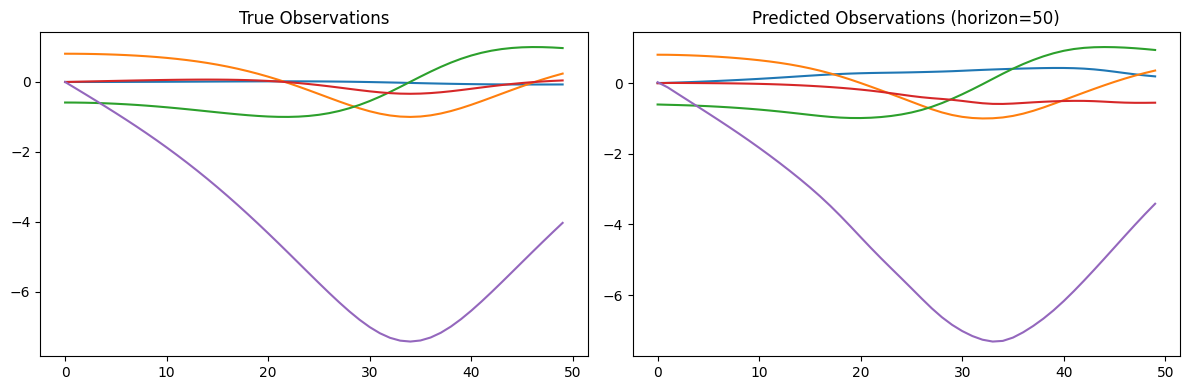

In [128]:
horizon = 50
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(obs_true)
axes[0].set_title('True Observations')
axes[1].plot(results[(0, angle_to_analyze)][f'obs_predicted_steps_{horizon}'])
axes[1].set_title(f'Predicted Observations (horizon={horizon})')
plt.tight_layout()

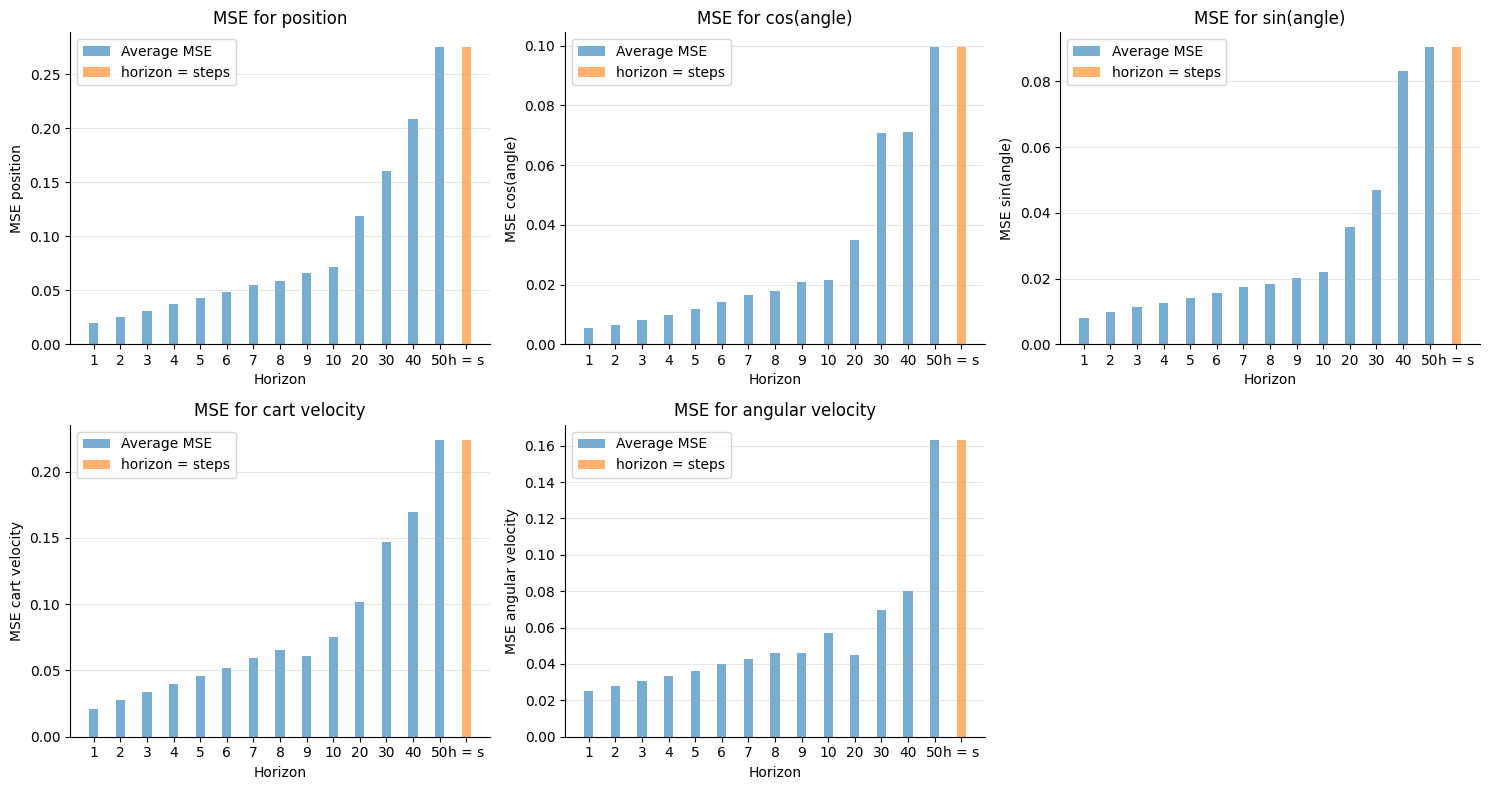

In [129]:
# Plot MSE as bar plot for each physical dimension
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    horizons_list = []
    mse_per_horizon_list = []

    for horizon in prediction_horizons:
        horizons_list.append(horizon)
        mse_per_horizon_list.append(
            metrics_by_horizon[horizon]['error_physical_per_dim'][dim])

    ax = axes[dim]

    # Get the single trajectory error for this dimension
    single_trajectory_error = results[(
        0, angle_to_analyze)]['error_physical_per_dim'][dim]

    # Create bar positions
    x = np.arange(len(horizons_list))
    width = 0.35

    # Plot bars for average MSE
    ax.bar(x, mse_per_horizon_list, width, label='Average MSE', alpha=0.6)

    # Plot single bar for single trajectory to the right
    ax.bar(len(horizons_list),
           single_trajectory_error,
           width,
           label='horizon = steps',
           alpha=0.6)

    ax.set_xlabel('Horizon')
    ax.set_ylabel(f'MSE {variable_names[dim]}')
    ax.set_title(f'MSE for {variable_names[dim]}')
    ax.set_xticks(list(x) + [len(horizons_list)])
    ax.set_xticklabels(horizons_list + ['h = s'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()


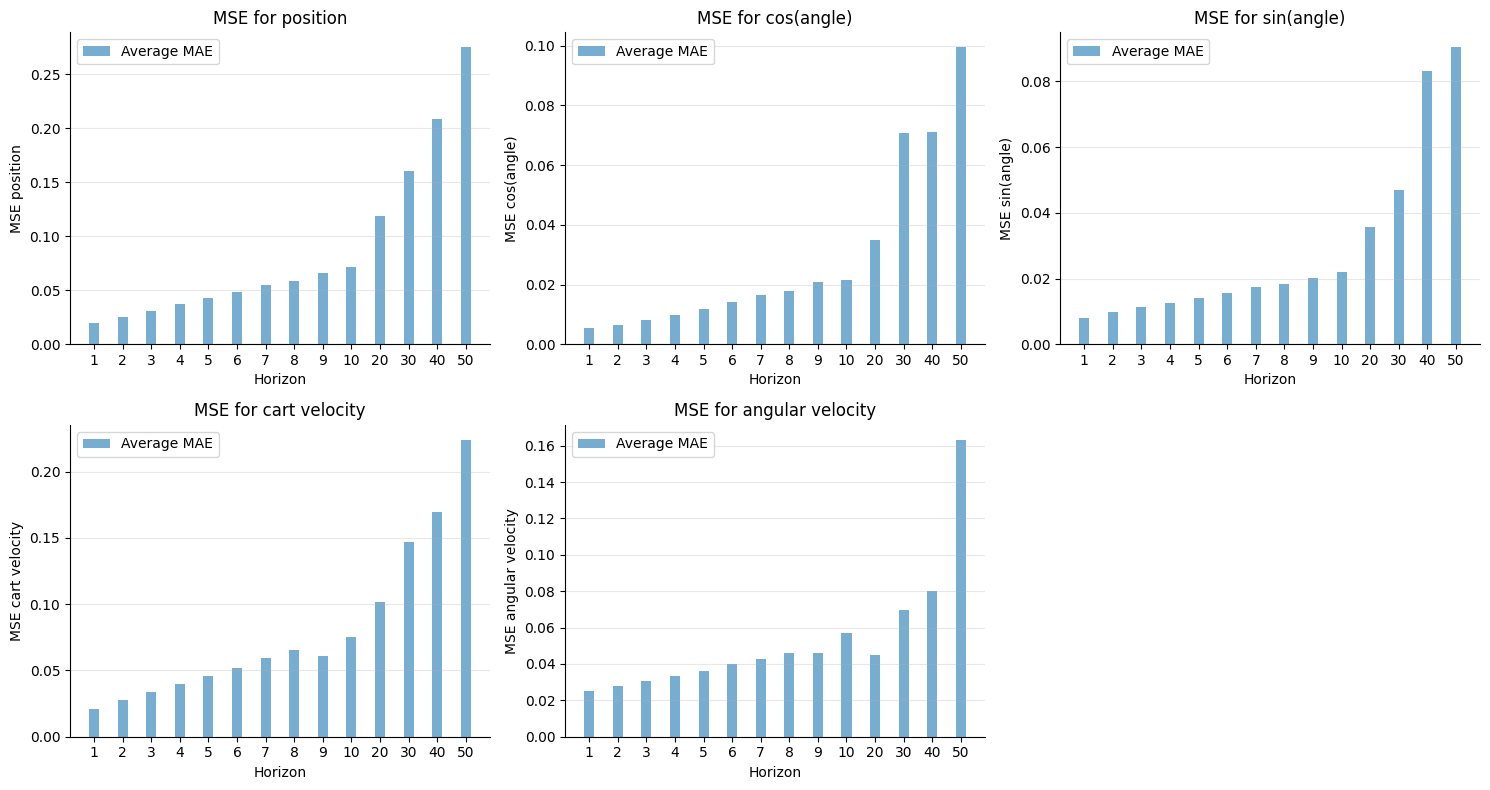

In [131]:
# Plot MSE as bar plot for each physical dimension
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    horizons_list = []
    mse_per_horizon_list = []

    for horizon in prediction_horizons:
        horizons_list.append(horizon)
        mse_per_horizon_list.append(
            metrics_by_horizon[horizon]['error_physical_per_dim'][dim])

    ax = axes[dim]

    # Create bar positions
    x = np.arange(len(horizons_list))
    width = 0.35

    # Plot bars for average MSE
    ax.bar(x, mse_per_horizon_list, width, label='Average MAE', alpha=0.6)

    ax.set_xlabel('Horizon')
    ax.set_ylabel(f'MSE {variable_names[dim]}')
    ax.set_title(f'MSE for {variable_names[dim]}')
    ax.set_xticks(list(x))
    ax.set_xticklabels(horizons_list)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()

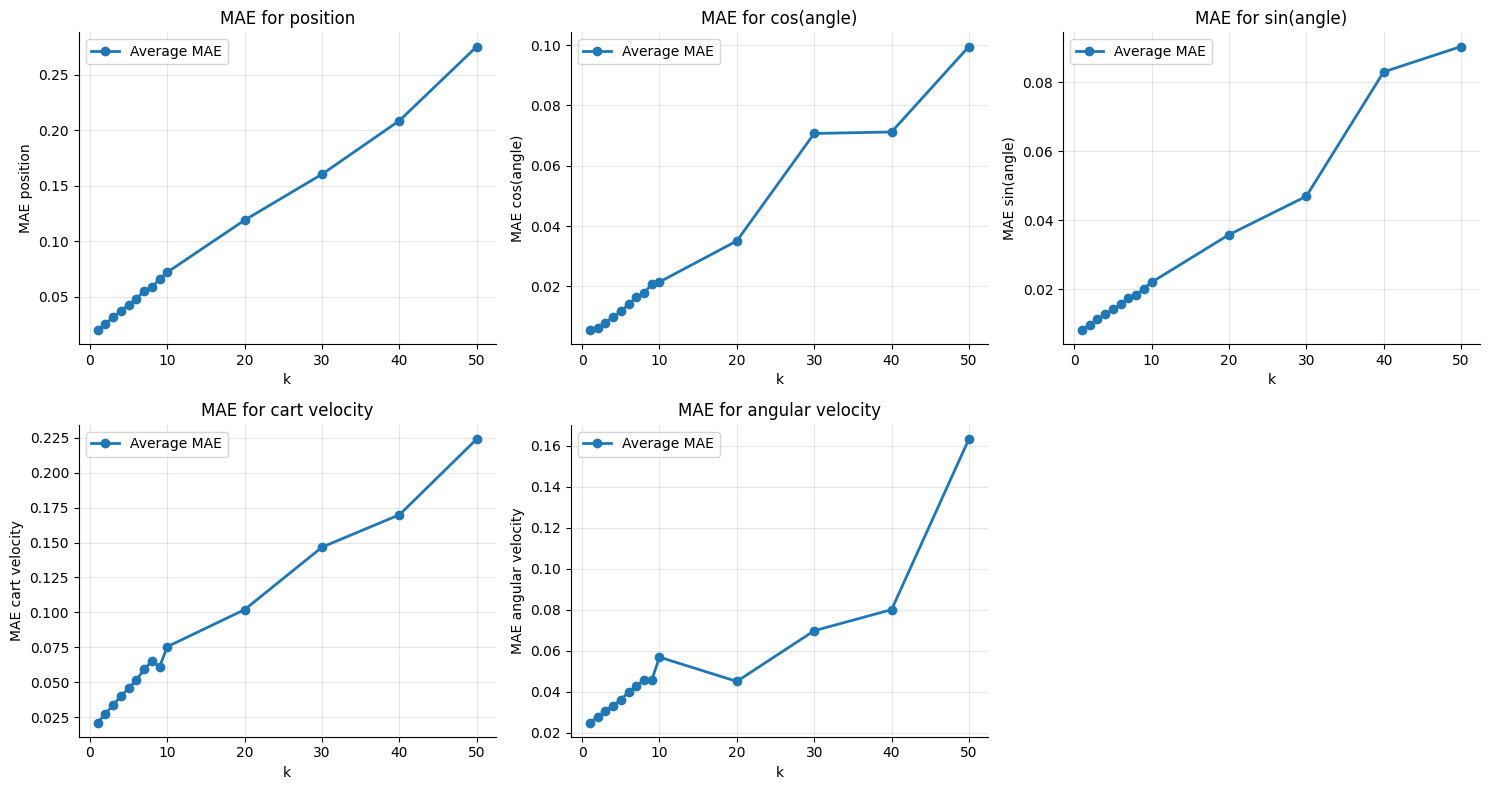

In [132]:
# Plot MSE as line plot for each physical dimension
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    horizons_list = []
    mse_per_horizon_list = []

    for horizon in prediction_horizons:
        horizons_list.append(horizon)
        mse_per_horizon_list.append(
            metrics_by_horizon[horizon]['error_physical_per_dim'][dim])

    ax = axes[dim]

    # Plot line for MSE
    ax.plot(horizons_list,
            mse_per_horizon_list,
            marker='o',
            linewidth=2,
            markersize=6,
            label='Average MAE')

    ax.set_xlabel('k')
    ax.set_ylabel(f'MAE {variable_names[dim]}')
    ax.set_title(f'MAE for {variable_names[dim]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()

In [152]:
horizon = 3
angle_to_show = 324
frames_predicted = reconstruct_cartpole_dmcontrol(
    results[(0, angle_to_show)][f'obs_predicted_steps_{horizon}'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

frames_true = reconstruct_cartpole_dmcontrol(
    results[(0, angle_to_show)][f'obs_true'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

100%|██████████| 50/50 [00:00<00:00, 50.96it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20260106_111602.mp4


100%|██████████| 50/50 [00:00<00:00, 51.19it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20260106_111603.mp4


In [153]:
# Create side-by-side video
import cv2
import imageio
# Get dimensions
height, width = frames_true[0].shape[:2]

# Create frames with side-by-side comparison
combined_frames = []
for frame_true, frame_pred in zip(frames_true, frames_predicted):
    # Create a canvas for side-by-side display with padding
    padding = 60
    combined = np.zeros((height + padding, width * 2 + 20, 3), dtype=np.uint8)

    # Add a subtle background for the title area
    combined[:padding, :] = (40, 40, 40)

    # Add titles with better positioning and styling
    # True trajectory title
    true_text = 'Ground Truth'
    true_text_size = cv2.getTextSize(true_text, cv2.FONT_HERSHEY_DUPLEX, 0.9,
                                     2)[0]
    true_x = (width - true_text_size[0]) // 2
    cv2.putText(combined, true_text, (true_x, 38), cv2.FONT_HERSHEY_DUPLEX, 0.9,
                (255, 255, 255), 2, cv2.LINE_AA)

    # Predicted trajectory title
    pred_text = 'Model Prediction'
    pred_text_size = cv2.getTextSize(pred_text, cv2.FONT_HERSHEY_DUPLEX, 0.9,
                                     2)[0]
    pred_x = width + 10 + (width - pred_text_size[0]) // 2
    cv2.putText(combined, pred_text, (pred_x, 38), cv2.FONT_HERSHEY_DUPLEX, 0.9,
                (255, 255, 255), 2, cv2.LINE_AA)

    # Add a separator line
    cv2.line(combined, (width + 10, padding), (width + 10, height + padding),
             (80, 80, 80), 2)

    # Place frames side by side
    combined[padding:, :width] = frame_true
    combined[padding:, width + 20:] = frame_pred

    combined_frames.append(combined)

# Save the combined video
video_path = f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/comparison_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
imageio.mimwrite(video_path, combined_frames, fps=30, macro_block_size=None)

print(
    f"Created side-by-side comparison video with {len(combined_frames)} frames at {video_path}"
)
len(frames_predicted)


Created side-by-side comparison video with 50 frames at /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/comparison_20260106_111604.mp4


[swscaler @ 0x5b82680] Warning: data is not aligned! This can lead to a speed loss


50